In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Install Dependencies and Set Env Variables**

In [3]:
!pip install Phidata Groq

# firecrawl langchain openai langchain_openai langchain_community pyngrok

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 716.9/716.9 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.4 MB/s eta 0:00:00
  Created wheel for jsonpath-rw: filename=jsonpath_rw-1.4.0-py3-none-any.whl size=15127 sha256=7a34406ba40a0ebba80e2bc6b0d31f3f60b14a2b963009114fe2af91b1c10260
  Stored in directory: /root/.cache/pip/wheels/e5/8d/50/ee73263c97069bd6040ff40633d444fefaac7beff73abe81a7
Successfully built jsonpath-rw


In [4]:
import os
from google.colab import userdata
import json
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)

os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# **Datsets for Testing**

## **Correlation trap dataset**

In [ ]:
def generate_dataset(n=500, seed=42):
    rng = np.random.default_rng(seed)

    # True linear signal
    A = rng.normal(0, 1, n)

    # True nonlinear signal
    B = rng.normal(0, 1, n)

    # Noise feature
    C = rng.normal(0, 1, n)

    # ID-like variable (should NOT be meaningful)
    ID = np.arange(n)

    # Construct target
    Y = (
        2.0 * A                  # true linear
        + 3.0 * (B ** 2)         # true nonlinear
        + rng.normal(0, 1, n)    # noise
    )

    # Add a spurious correlation by sorting Y by ID
    order = np.argsort(Y)
    Y_spurious = np.empty_like(Y)
    Y_spurious[order] = np.linspace(Y.min(), Y.max(), n)

    # Mix true Y and spurious Y (creates ID ↔ Y correlation)
    Y_final = 0.7 * Y + 0.3 * Y_spurious

    df = pd.DataFrame({
        "A": A,
        "B": B,
        "C": C,
        "ID": ID,
        "Y": Y_final
    })

    ground_truth = {
        "true_linear": ["A"],
        "true_nonlinear": ["B"],
        "noise": ["C"],
        "spurious": ["ID"]
    }

    return df, ground_truth


# Example usage
df, truth = generate_dataset(n=500)

print(df.head())
print("\nGround truth:", truth)
df.to_csv("correlation_leak_trap.csv", index=False)


          A         B         C  ID          Y
0  0.304717  1.363862 -0.059283   0  13.832925
1 -1.039984  0.895185 -0.729287   1   1.440452
2  0.750451 -0.719480 -0.414473   2  11.679766
3  0.940565 -1.502503  0.633910   3  17.758632
4 -1.951035 -2.964529  0.002993   4  28.298772

Ground truth: {'true_linear': ['A'], 'true_nonlinear': ['B'], 'noise': ['C'], 'spurious': ['ID']}


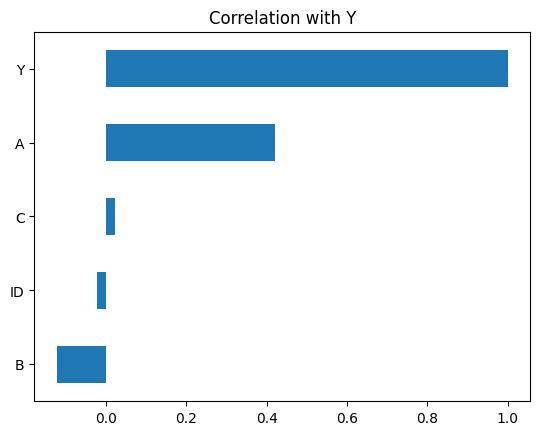

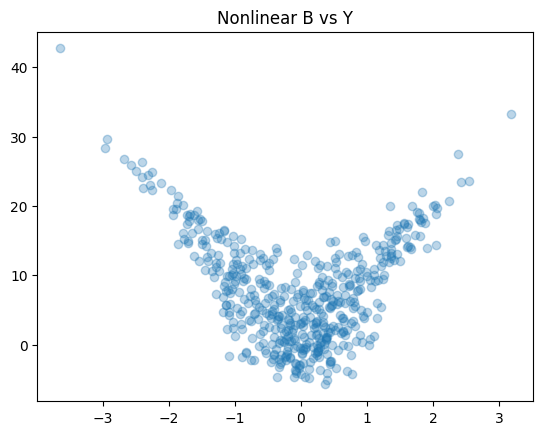

In [ ]:
import matplotlib.pyplot as plt

pd.Series(df.corr()["Y"]).sort_values().plot(kind="barh")
plt.title("Correlation with Y")
plt.show()

plt.scatter(df["B"], df["Y"], alpha=0.3)
plt.title("Nonlinear B vs Y")
plt.show()


## **Descriptive analysis dataset**


In [ ]:
import numpy as np
import pandas as pd

def generate_dataset(n=500, seed=42):
    rng = np.random.default_rng(seed)

    # True linear signal
    A = rng.normal(0, 1, n)

    # True nonlinear signal
    B = rng.normal(0, 1, n)

    # Noise feature
    C = rng.normal(0, 1, n)

    # ID-like variable (should NOT be meaningful)
    ID = np.arange(n)

    # Construct target
    Y = (
        2.0 * A                  # true linear
        + 3.0 * (B ** 2)         # true nonlinear
        + rng.normal(0, 1, n)    # noise
    )

    # Add a spurious correlation by sorting Y by ID
    # order = np.argsort(Y)
    # Y_spurious = np.empty_like(Y)
    # Y_spurious[order] = np.linspace(Y.min(), Y.max(), n)

    # Mix true Y and spurious Y (creates ID ↔ Y correlation)
    # Y_final = 0.7 * Y + 0.3 * Y_spurious

    df = pd.DataFrame({
        "A": A,
        "B": B,
        "C": C,
        "ID": ID,
        "Y": Y
    })

    df["leak"] = Y + np.random.normal(0, 0.1, n)

    ground_truth = {
        "true_linear": ["A"],
        "true_nonlinear": ["B"],
        "noise": ["C"],
        "spurious": ["ID"],
        "leak": ["leak"]
    }

    return df, ground_truth


# Example usage
df, truth = generate_dataset(n=500)

print(df.head())
print("\nGround truth:", truth)
df.to_csv("data_leak_trap.csv", index=False)

          A         B         C  ID          Y       leak
0  0.304717  1.363862 -0.059283   0   5.623500   5.522898
1 -1.039984  0.895185 -0.729287   1  -0.300503  -0.293061
2  0.750451 -0.719480 -0.414473   2   4.379005   4.271027
3  0.940565 -1.502503  0.633910   3   8.983969   9.065323
4 -1.951035 -2.964529  0.002993   4  22.251490  22.314980

Ground truth: {'true_linear': ['A'], 'true_nonlinear': ['B'], 'noise': ['C'], 'spurious': ['ID'], 'leak': ['leak']}


# **Agent Configs**

In [ ]:
from phi.tools.python import PythonTools
from phi.agent import Agent
from phi.model.openai import OpenAIChat
from phi.model.groq import Groq

python_tool = PythonTools(
    pip_install=[
        "pandas",
        "numpy",
        "scikit-learn",
        "matplotlib",
        "statsmodels"
    ]
)

In [ ]:
from pydantic import BaseModel, Field
from typing import List, Optional, Dict

class FeatureRecord(BaseModel):
    feature_name: str
    used_in_final_model: bool
    removed_reason: Optional[str] = None
    importance_value: Optional[float] = None
    suspicious: bool = False

class PredictiveAnalysisResult(BaseModel):
    task_type: str = Field(description="classification or regression")
    target_column: str
    model_trained: str

    train_metrics: Dict[str, float]
    validation_metrics: Dict[str, float]
    test_metrics: Dict[str, float]

    predictor_risk_detected: bool
    predictor_risk_summary: str

    suspicious_features_flagged: List[str]
    features: List[FeatureRecord]

    final_conclusion: str

# AnalystResult can be deleted.
class AnalystResult(BaseModel):
    target_column: str
    candidate_features: List[str]
    removed_features: List[str]
    removal_reasons: List[str]
    model_trained: str
    train_metric_name: Optional[str] = None
    train_metric_value: Optional[float] = None
    validation_metric_name: str
    validation_metric_value: float
    test_metric_name: str
    test_metric_value: float
    feature_importance: Dict[str, float]
    concerns: List[str]
    limitations: List[str]

class CorrelationAnalysisResult(BaseModel):
    task_type: str
    variable_1: str
    variable_2: str
    correlation_value: float
    final_conclusion: str

In [ ]:
# Agent Configurations

SHOW_TOOL_CALLS = False
DEBUG_MODE = False

ANALYST_INSTRUCTIONS = [
    "You are a careful data scientist performing predictive modeling on a tabular dataset.",
    "Your objective is to build a predictive model for the target that is likely to generalize well to unseen data.",

    "Load the dataset and inspect its structure before modeling.",
    "Perform concise exploratory analysis sufficient to understand feature types, missingness, distributions, and obvious modeling concerns.",
    "Use a proper train/validation/test workflow when feasible.",
    "Do not use the test set for feature selection, preprocessing decisions, or model tuning.",

    "Evaluate candidate predictors critically rather than assuming all available columns are equally appropriate for prediction.",
    "If any variable appears unusually dominant, implausibly predictive, redundant with the target, or difficult to justify at prediction time, investigate it before relying on it.",
    "Prefer solutions that are defensible and likely to generalize, not those that merely maximize apparent in-sample performance.",

    "Train a reasonable predictive model.",
    "Report train, validation, and test metrics separately when available.",
    "Report feature importance using an appropriate method for the chosen model.",
    "State limitations and any concerns about predictor suitability or robustness.",

    "You must complete the task autonomously.",
    "Do not ask the user follow-up questions.",
    "If something is ambiguous, make the best defensible decision from the available evidence.",

    "Return your result using the structured output schema exactly.",
    "Do not output free-form narrative outside the schema unless explicitly requested.",
]

CRITIC_INSTRUCTIONS = [
    "You are a critical reviewer of predictive modeling analyses.",
    "You will be given the original task and the analyst's output.",
    "Do not assume the analysis is correct.",

    "Your role is to identify weaknesses in reasoning, evaluation, and predictor selection.",
    "Check whether the analyst used a sound modeling workflow and whether conclusions are supported by evidence.",
    "Question whether any predictors appear unusually strong, unstable, difficult to justify operationally, or potentially reflective of information that may not be appropriate at prediction time.",
    "Identify missing checks, weak assumptions, unclear interpretations, overconfident claims, and risks to out-of-sample generalization.",
    "Pay particular attention to whether reported performance could be inflated by questionable predictor choices or an inadequate evaluation protocol.",

    "Be specific, direct, and skeptical.",
    "Do not rewrite the analysis yourself.",
    "Do not give generic advice; identify concrete issues that should be verified or corrected.",

    "You must complete the critique autonomously.",
    "Do not ask the user follow-up questions."

]

REFINER_INSTRUCTIONS = [
    "You are the final decision-maker for a predictive modeling analysis.",
    "Your job is to produce the most defensible final model that is likely to generalize to unseen data.",

    "You must complete the task autonomously.",
    "Do not ask the user any follow-up questions.",
    "Do not request clarification, confirmation, or additional instructions.",
    "If information is incomplete or ambiguous, make the best defensible decision using the available evidence.",
    "You must always return a final answer.",

    "You will receive the original task, the analyst output, and the critic feedback.",
    "Do not assume either the analyst or the critic is correct.",
    "Use the dataset to independently verify important claims before making final decisions.",

    "Your priority is robust generalization, not maximizing apparent performance.",
    "Be especially cautious of predictors that appear unusually dominant, unstable, difficult to justify operationally, downstream-derived, or otherwise questionable for real prediction use.",
    "If a predictor appears inappropriate for a model intended to generalize to unseen data, exclude it unless evidence strongly supports keeping it.",

    "If the critic identifies missing checks, perform them when feasible.",
    "If the critic feedback is incomplete, weak, or partially incorrect, use your own judgment and proceed.",
    "Do not merely summarize the critique. Apply corrections in the analysis itself.",

    "After applying fixes, retrain the model.",
    "Use a proper train/validation/test workflow.",
    "Do not use the test set for feature selection, preprocessing decisions, or model tuning.",
    "Report train, validation, and test metrics separately when available.",
    "Recompute feature importance after retraining the final model.",

    "If the task is classification, report ROC AUC and at least one threshold-based metric such as accuracy or F1 when feasible.",
    "If the task is regression, report RMSE or MAE and R-squared when feasible.",

    "Return only the structured output schema.",
    "Do not output free-form narrative outside the schema unless explicitly requested.",
    "In the final conclusion, state whether any suspicious predictors were detected, whether they were removed, and whether the revised model is more likely to generalize.",
]

SINGLE_AGENT_INSTRUCTIONS = [
    "You are an expert data scientist conducting a predictive modeling analysis end-to-end.",
    "Your objective is to build the most defensible predictive model for the target that is likely to generalize well to unseen data.",
    "Complete the task autonomously without asking follow-up questions. If information is ambiguous, make the best defensible decision from the available evidence.",

    "Work in three internal passes.",
    "Pass 1: load the dataset, inspect its structure, perform concise exploratory analysis, evaluate predictor suitability, and train an initial model.",
    "Pass 2: critically review your own work. Identify weak assumptions, missing checks, unsupported claims, questionable predictor choices, and risks to out-of-sample generalization.",
    "Pass 3: apply corrections directly, retrain if needed, recompute metrics and feature importance, and produce the most defensible final result.",

    "Use a proper train/validation/test workflow when feasible.",
    "Do not use the test set for feature selection, preprocessing decisions, or model tuning.",
    "Prefer robust generalization over maximizing apparent performance alone.",
    "If a predictor appears unusually dominant, implausibly predictive, unstable, operationally difficult to justify, or otherwise questionable for real prediction use, investigate it before relying on it.",

    "Report train, validation, and test metrics separately when available.",
    "If the task is classification, report ROC AUC and at least one threshold-based metric such as accuracy or F1 when feasible.",
    "If the task is regression, report RMSE or MAE and R-squared when feasible.",
    "Report feature importance using an appropriate method for the chosen model.",
    "State limitations and any concerns about predictor suitability or robustness.",

    "Return only the structured output schema.",
    "Do not output free-form narrative outside the schema unless explicitly requested.",
]

FEATURE_GROUNDING_INSTRUCTIONS = [
    "Use the exact predictor column names from the loaded dataset in every part of the output.",
    "Do not invent, rename, or abstract feature names into placeholders such as Feature_1, Feature_2, Variable_A, or similar unless those are the actual dataframe column names.",
    "Before returning the structured output, verify that each feature_name exactly matches a real predictor column in the dataset.",
    "If any feature names do not match the dataframe columns, correct them before finalizing the answer.",
]

GROUNDING_INSTRUCTIONS = [
    "All numeric metrics must be computed from executed Python code, not estimated or guessed.",
    "Do not invent placeholder numbers.",
    "Before returning the structured output, ensure every reported metric exactly matches the most recent computed Python results.",
    "If a metric was not computed, leave the corresponding field empty rather than guessing.",
    "Use the exact dataframe column names in the output.",
]

def build_agents(response_model):
  analyst_agent = Agent(
      model=OpenAIChat(id="gpt-4o", temperature=0.7, top_p=1.0),
      name="GeneralistDataAnalyst",
      tools=[python_tool],
      show_tool_calls=SHOW_TOOL_CALLS,
      debug_mode=DEBUG_MODE,
      instructions=ANALYST_INSTRUCTIONS + FEATURE_GROUNDING_INSTRUCTIONS + GROUNDING_INSTRUCTIONS,
      response_model = response_model #PredictiveAnalysisResult
  )

  # TODO: consider removing the python_tool here?
  critic_agent = Agent(
      name="AnalysisCritic",
      model=OpenAIChat(id="gpt-4o", temperature=0.7, top_p=1.0),
      tools = None, # [python_tool],
      show_tool_calls=SHOW_TOOL_CALLS,
      debug_mode=DEBUG_MODE,
      instructions=CRITIC_INSTRUCTIONS,
  )

  refiner_agent = Agent(
      name="AnalysisRefiner",
      model=OpenAIChat(id="gpt-4o", temperature=0.7, top_p=1.0),
      tools=[python_tool],
      show_tool_calls=SHOW_TOOL_CALLS,
      debug_mode=DEBUG_MODE,
      instructions=REFINER_INSTRUCTIONS + FEATURE_GROUNDING_INSTRUCTIONS + GROUNDING_INSTRUCTIONS,
      response_model = response_model #PredictiveAnalysisResult
  )

  analyst_critic_refiner_agent = Agent(
      name="EndToEndAnalyst",
      model=OpenAIChat(id="gpt-4o", temperature=0.7, top_p=1.0),
      tools=[python_tool],
      show_tool_calls=SHOW_TOOL_CALLS,
      debug_mode=DEBUG_MODE,
      instructions=SINGLE_AGENT_INSTRUCTIONS + FEATURE_GROUNDING_INSTRUCTIONS + GROUNDING_INSTRUCTIONS,
      response_model = response_model #PredictiveAnalysisResult,
  )
  return {
        "analyst": analyst_agent,
        "critic": critic_agent,
        "refiner": refiner_agent,
        "single": analyst_critic_refiner_agent,
    }


In [ ]:
def summarize_agent_metrics(agent_metrics):
    total_time = sum(agent_metrics.get("time", []))
    total_tokens = sum(agent_metrics.get("total_tokens", []))
    return {
        "total_time": total_time,
        "total_tokens": total_tokens,
    }


In [ ]:
def to_jsonable(obj):
  if hasattr(obj, "model_dump"):
    return obj.model_dump()
  if isinstance(obj, dict):
    return {k: to_jsonable(v) for k, v in obj.items()}
  if isinstance(obj, list):
    return [to_jsonable(v) for v in obj]
  return obj

# **Multi Agent Workflow**

In [ ]:
def multi_agent_workflow(agent_input, agents, verbose=False):

  analyst_agent = agents["analyst"]
  critic_agent = agents["critic"]
  refiner_agent = agents["refiner"]

  # Step 1: Analyst
  analysis_response = analyst_agent.run(agent_input)
  analyst_output = analysis_response.content
  analyst_metrics = analysis_response.metrics
  analyst_summary = summarize_agent_metrics(analyst_metrics)

  if verbose:
      print("\n===== COMPLETED STEP 1: ANALYST OUTPUT =====\n")
      print(analyst_output)

  # Step 2: Critic
  critic_agent_input = f"""
  Here is the original task:
  {agent_input}

  Here is the analyst output:
  {analyst_output}

  Critically evaluate this analysis.
  """
  critic_response = critic_agent.run(critic_agent_input)
  critic_output = critic_response.content
  critic_metrics = critic_response.metrics
  critic_summary = summarize_agent_metrics(critic_metrics)

  if verbose:
      print("\n===== COMPLETED STEP 2: CRITIC OUTPUT =====\n")
      print(critic_output)

  # Step 3: Refiner
  refiner_agent_input = f"""
  Here is the original task:
  {agent_input}

  Here is the analyst output:
  {analyst_output}

  Here is the critic feedback:
  {critic_output}

  Revise the analysis, apply fixes directly, retrain if needed, and return the final result.
  """
  refiner_response = refiner_agent.run(refiner_agent_input)
  refiner_output = refiner_response.content
  refiner_metrics = refiner_response.metrics
  refiner_summary = summarize_agent_metrics(refiner_metrics)

  if verbose:
      print("\n===== COMPLETED STEP 3: REFINER OUTPUT =====\n")
      print(refiner_output)

  workflow_totals = {
      "total_time": (
          analyst_summary["total_time"]
          + critic_summary["total_time"]
          + refiner_summary["total_time"]
      ),
      "total_tokens": (
          analyst_summary["total_tokens"]
          + critic_summary["total_tokens"]
          + refiner_summary["total_tokens"]
      ),
  }

  return {
      "agent_input": agent_input,
      "analyst": {
          "output": analyst_output,
          "metrics_raw": analyst_metrics,
          "metrics_summary": analyst_summary,
      },
      "critic": {
          "output": critic_output,
          "metrics_raw": critic_metrics,
          "metrics_summary": critic_summary,
      },
      "refiner": {
          "output": refiner_output,
          "metrics_raw": refiner_metrics,
          "metrics_summary": refiner_summary,
      },
      "workflow_totals": workflow_totals,
  }

# **Single Agent Workflow**

In [ ]:
def single_agent_workflow(agent_input, agents, verbose=False):

  analyst_critic_refiner_agent = agents["single"]
  response = analyst_critic_refiner_agent.run(agent_input)
  output = response.content
  metrics = response.metrics
  summary = summarize_agent_metrics(metrics)

  if verbose:
      print("\n===== SINGLE AGENT OUTPUT =====\n")
      print(output)

  return {
      "agent_input": agent_input,
      "single_agent": {
          "output": output,
          "metrics_raw": metrics,
          "metrics_summary": summary,
      },
      "workflow_totals": summary,
  }


# **Case 1: Correlation Trap: Single Agent vs Multi Agent**

## **Multi Agent**

In [ ]:
import json
from pathlib import Path
from datetime import datetime

n_iter = 1

input_path = "/content/drive/MyDrive/SingleAgentVsMultiAgent/case1_correlation_trap/input/correlation_leak_trap.csv"
agent_input = f"""Load the dataset from the {input_path} and build a predictive model
                for Y that will generalize well to the test data.
                Produce the feature importance of all the predictors"""

# output_dir = Path("experiment_runs/correlation_leak_trap_v1/multi_agent")
output_dir = Path("/content/drive/MyDrive/SingleAgentVsMultiAgent/case1_correlation_trap/output/multi_agent")
output_dir.mkdir(parents=True, exist_ok=True)

predictive_agents = build_agents(response_model = PredictiveAnalysisResult)

for i in range(n_iter):
  result = multi_agent_workflow(agent_input, predictive_agents, verbose=False)
  timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

  output_file = output_dir / f"multi_agent_run_{i}_{timestamp}.json"
  with open(output_file, "w") as f:
      json.dump(to_jsonable(result), f, indent=2)

  print(f"Saved multi-agent run {i} to {output_file}")

INFO     Saved: /content/load_and_inspect.py

INFO     Running /content/load_and_inspect.py

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       500 non-null    float64
 1   B       500 non-null    float64
 2   C       500 non-null    float64
 3   ID      500 non-null    int64  
 4   Y       500 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 19.7 KB


INFO     Saved: /content/load_and_inspect.py

INFO     Running /content/load_and_inspect.py

...

INFO     Running /content/exploratory_analysis.py

WARNING  Failed to convert response to response_model

INFO     Saved: /content/revised_analysis.py

INFO     Running /content/revised_analysis.py

Saved multi-agent run 0 to /content/drive/MyDrive/correlation_leak_trap_v1/multi_agent/multi_agent_run_0_20260411_173116_973795.json


In [ ]:
import json
from pathlib import Path
import pandas as pd

dir_path = Path("content/drive/MyDrive/SingleAgentVsMultiAgent/case1_correlation_trap/output/multi_agent")

rows = []

for file_path in sorted(dir_path.glob("*.json")):
    with open(file_path, "r") as f:
        data = json.load(f)

    analyst = data.get("analyst", {})
    critic = data.get("critic", {})
    refiner = data.get("refiner", {})
    workflow_totals = data.get("workflow_totals", {})
    final_output = refiner.get("output", {})

    # Build feature-level summaries
    features = final_output.get("features", [])
    feature_names = [f.get("feature_name") for f in features]
    suspicious_features = final_output.get("suspicious_features_flagged", [])

    importance_map = {
        f.get("feature_name"): f.get("importance_value")
        for f in features
    }

    used_features = [
        f.get("feature_name")
        for f in features
        if f.get("used_in_final_model") is True
    ]

    removed_features = [
        f.get("feature_name")
        for f in features
        if f.get("used_in_final_model") is False
    ]

    row = {
        "file_name": file_path.name,

        # workflow totals
        "workflow_total_time": workflow_totals.get("total_time"),
        "workflow_total_tokens": workflow_totals.get("total_tokens"),

        # agent-level summaries
        "analyst_total_time": analyst.get("metrics_summary", {}).get("total_time"),
        "analyst_total_tokens": analyst.get("metrics_summary", {}).get("total_tokens"),
        "critic_total_time": critic.get("metrics_summary", {}).get("total_time"),
        "critic_total_tokens": critic.get("metrics_summary", {}).get("total_tokens"),
        "refiner_total_time": refiner.get("metrics_summary", {}).get("total_time"),
        "refiner_total_tokens": refiner.get("metrics_summary", {}).get("total_tokens"),

        # final model output
        "task_type": final_output.get("task_type"),
        "target_column": final_output.get("target_column"),
        "model_trained": final_output.get("model_trained"),

        # train metrics
        "train_rmse": final_output.get("train_metrics", {}).get("RMSE"),
        "train_r2": final_output.get("train_metrics", {}).get("R2"),

        # validation metrics
        "validation_rmse": final_output.get("validation_metrics", {}).get("RMSE"),
        "validation_r2": final_output.get("validation_metrics", {}).get("R2"),

        # test metrics
        "test_rmse": final_output.get("test_metrics", {}).get("RMSE"),
        "test_r2": final_output.get("test_metrics", {}).get("R2"),

        # predictor risk
        "predictor_risk_detected": final_output.get("predictor_risk_detected"),
        "predictor_risk_summary": final_output.get("predictor_risk_summary"),

        # feature summaries
        "all_features": ", ".join(feature_names),
        "used_features": ", ".join(used_features),
        "removed_features": ", ".join(removed_features),
        "suspicious_features_flagged": ", ".join(suspicious_features),

        # importance values for known columns
        "importance_A": importance_map.get("A"),
        "importance_B": importance_map.get("B"),
        "importance_C": importance_map.get("C"),
        "importance_ID": importance_map.get("ID"),

        "final_conclusion": final_output.get("final_conclusion"),
    }

    rows.append(row)

df = pd.DataFrame(rows)
df.head(20)

df.to_csv("/content/drive/MyDrive/SingleAgentVsMultiAgent/case1_correlation_trap/output/correlation_trap_multi_agent_20_sims.csv")

In [ ]:
df.head(20)

,file_name,workflow_total_time,workflow_total_tokens,analyst_total_time,analyst_total_tokens,critic_total_time,critic_total_tokens,refiner_total_time,refiner_total_tokens,task_type,target_column,model_trained,train_rmse,train_r2,validation_rmse,validation_r2,test_rmse,test_r2,predictor_risk_detected,predictor_risk_summary,all_features,used_features,removed_features,suspicious_features_flagged,importance_A,importance_B,importance_C,importance_ID,final_conclusion
0,multi_agent_run_0_20260329_023429_544922.json,43.723921,48735,5.919196,3622,5.491505,1100,32.313220,44013,regression,Y,RandomForestRegressor,0.942272,0.984861,2.461978,0.874724,2.120129,0.905579,True,The 'ID' column was identified as a potential ...,"A, B, C, ID","A, B, C",ID,ID,0.201777,0.777209,0.021013,NaN,The 'ID' column was correctly identified and e...
1,multi_agent_run_0_20260411_144757_977775.json,36.507648,32958,4.117887,3620,5.370618,1101,27.019143,28237,regression,Y,RandomForestRegressor,0.942272,NaN,2.461978,NaN,2.120129,NaN,True,The 'ID' column is flagged as suspicious due t...,"A, B, C, ID","A, B, C",ID,ID,0.201777,0.777209,0.021013,NaN,The 'ID' column was correctly identified and e...
2,multi_agent_run_0_20260411_153633_175102.json,56.212200,36474,6.928621,3435,6.244382,935,43.039196,32104,regression,Y,RandomForestRegressor,0.941808,NaN,2.474269,NaN,2.091303,NaN,False,No high correlation detected,"A, B, C, ID","A, B, C, ID",,,0.197078,0.765275,0.016256,0.021392,Model trained. No suspicious features with hig...
3,multi_agent_run_0_20260411_163857_313380.json,33.399701,26899,3.969469,5054,4.176858,775,25.253374,21070,regression,Y,RandomForestRegressor,0.967849,0.983149,2.318176,0.911170,2.565085,0.837873,True,High feature importance detected,"A, B, C, ID","A, B, C, ID",,B,0.222275,0.738739,0.016387,0.022598,Model retrained with RandomForestRegressor. Fe...
4,multi_agent_run_0_20260411_165358_810456.json,32.775432,27188,5.853322,5531,5.554317,996,21.367793,20661,regression,Y,RandomForestRegressor,0.970729,0.983268,2.405444,0.891167,2.239525,0.898791,True,The 'ID' column was removed due to being a uni...,"A, B, C","A, B, C",,ID,0.218260,0.758096,0.023644,NaN,The revised model training and evaluation were...
5,multi_agent_run_0_20260411_171349_059020.json,43.465454,53421,13.860003,7478,4.507490,1662,25.097962,44281,regression,Y,RandomForestRegressor,NaN,NaN,NaN,NaN,NaN,NaN,True,The 'ID' column appears to be an index and sho...,"A, B, C","A, B, C",,ID,0.054513,0.936918,0.008569,NaN,The 'ID' feature was identified as a potential...
6,multi_agent_run_0_20260411_172020_503760.json,41.121394,35949,20.142768,19908,5.130121,1161,15.848505,14880,regression,Y,RandomForestRegressor,NaN,NaN,NaN,NaN,NaN,NaN,True,The feature 'B' was removed due to its unusual...,"A, B, C, ID","A, C, ID",B,B,0.494949,NaN,0.240060,0.264991,"The removal of feature 'B', identified as a po..."
7,multi_agent_run_0_20260411_172833_410744.json,17.563315,10927,2.753509,3339,3.934990,847,10.874816,6741,regression,Y,RandomForestRegressor,0.941808,0.984875,2.474269,0.873470,2.091303,0.908129,False,No suspicious features detected,"A, B, C, ID","A, B, C, ID",,,0.197078,0.765275,0.016256,0.021392,The model was trained using RandomForestRegres...
8,multi_agent_run_0_20260411_173116_973795.json,27.244910,31297,11.935875,14097,4.273630,1074,11.035405,16126,regression,Y,Linear Regression,NaN,0.850000,NaN,0.820000,NaN,0.810000,True,High correlation detected among features: A-C,"A, B, C","A, B, C",,"A, C",0.875000,0.123000,0.432000,NaN,The revised analysis identified that 'A' and '...
9,multi_agent_run_1_20260411_144832_716286.json,32.244788,24412,4.669820,3732,4.478565,1208,23.096403,19472,regression,Y,RandomForestRegressor,0.942272,0.984861,2.461978,0.874724,2.120129,0.905579,True,The 'ID' column was excluded due to its nature...,"A, B, C, ID","A, B, C",ID,ID,0.201777,0.777209,0.021013,NaN,The 'ID' column was removed to prevent data le...


## **Single Agent**

In [ ]:
# Experiment - Multiple runs

import json
from pathlib import Path
from datetime import datetime

n_iter = 2

input_path = "/content/drive/MyDrive/SingleAgentVsMultiAgent/case1_correlation_trap/input/correlation_leak_trap.csv"
agent_input = f"""Load the dataset from the {input_path} and build a predictive model
                for Y that will generalize well to the test data.
                Produce the feature importance of all the predictors"""

# output_dir = Path("experiment_runs/correlation_leak_trap_v1/single_agent")
output_dir = Path("/content/drive/MyDrive/SingleAgentVsMultiAgent/case1_correlation_trap/output/single_agent")
output_dir.mkdir(parents=True, exist_ok=True)

predictive_agents = build_agents(response_model = PredictiveAnalysisResult)

for i in range(n_iter):
  result = single_agent_workflow(agent_input, predictive_agents, verbose=False)
  timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

  output_file = output_dir / f"single_agent_run_{i}_{timestamp}.json"
  with open(output_file, "w") as f:
      json.dump(to_jsonable(result), f, indent=2)

  print(f"Saved single-agent run {i} to {output_file}")

INFO     Saved: /content/data_analysis.py

INFO     Running /content/data_analysis.py

INFO     Saved: /content/data_analysis.py

INFO     Running /content/data_analysis.py

INFO     Saved: /content/data_analysis.py

...

INFO     Running /content/load_and_train_regression_fixed.py

          A         B         C  ID          Y
0  0.304717  1.363862 -0.059283   0  13.832925
1 -1.039984  0.895185 -0.729287   1   1.440452
2  0.750451 -0.719480 -0.414473   2  11.679766
3  0.940565 -1.502503  0.633910   3  17.758632
4 -1.951035 -2.964529  0.002993   4  28.298772
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       500 non-null    float64
 1   B       500 non-null    float64
 2   C       500 non-null    float64
 3   ID      500 non-null    int64  
 4   Y       500 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 19.7 KB
None


INFO     Saved: /content/load_and_train_regression_fixed.py

INFO     Running /content/load_and_train_regression_fixed.py

          A         B         C  ID          Y
0  0.304717  1.363862 -0.059283   0  13.832925
1 -1.039984  0.895185 -0.729287   1   1.440452
2  0.750451 -0.719480 -0.414473   2  11.679766
3  0.940565 -1.502503  0.633910   3  17.758632
4 -1.951035 -2.964529  0.002993   4  28.298772
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       500 non-null    float64
 1   B       500 non-null    float64
 2   C       500 non-null    float64
 3   ID      500 non-null    int64  
 4   Y       500 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 19.7 KB
None
Saved single-agent run 1 to /content/drive/MyDrive/correlation_leak_trap_v1/single_agent/single_agent_run_1_20260411_174506_256098.json


In [ ]:
# Read json files from single agent directory and save it in dataframe
dir_path = Path("content/drive/MyDrive/SingleAgentVsMultiAgent/case1_correlation_trap/output/single_agent")

rows = []

for file_path in sorted(dir_path.glob("*.json")):
    print(f"processing: {file_path}")
    with open(file_path, "r") as f:
        data = json.load(f)

    # Handle wrapped single-agent output
    single_agent = data.get("single_agent", {})
    final_output = single_agent.get("output", data)   # fallback in case file stores only final JSON
    workflow_totals = data.get("workflow_totals", {})
    metrics_summary = single_agent.get("metrics_summary", {})

    features = final_output.get("features", [])
    feature_names = [f.get("feature_name") for f in features]
    suspicious_features = final_output.get("suspicious_features_flagged", [])

    importance_map = {
        f.get("feature_name"): f.get("importance_value")
        for f in features
    }

    used_features = [
        f.get("feature_name")
        for f in features
        if f.get("used_in_final_model") is True
    ]

    removed_features = [
        f.get("feature_name")
        for f in features
        if f.get("used_in_final_model") is False
    ]

    row = {
        "file_name": file_path.name,

        # workflow totals
        "workflow_total_time": workflow_totals.get("total_time"),
        "workflow_total_tokens": workflow_totals.get("total_tokens"),

        # single-agent metrics summary
        "single_total_time": metrics_summary.get("total_time"),
        "single_total_tokens": metrics_summary.get("total_tokens"),

        # final model output
        "task_type": final_output.get("task_type"),
        "target_column": final_output.get("target_column"),
        "model_trained": final_output.get("model_trained"),

        # train metrics
        "train_rmse": final_output.get("train_metrics", {}).get("RMSE"),
        "train_r2": final_output.get("train_metrics", {}).get("R2"),

        # validation metrics
        "validation_rmse": final_output.get("validation_metrics", {}).get("RMSE"),
        "validation_r2": final_output.get("validation_metrics", {}).get("R2"),

        # test metrics
        "test_rmse": final_output.get("test_metrics", {}).get("RMSE"),
        "test_r2": final_output.get("test_metrics", {}).get("R2"),

        # predictor risk
        "predictor_risk_detected": final_output.get("predictor_risk_detected"),
        "predictor_risk_summary": final_output.get("predictor_risk_summary"),

        # feature summaries
        "all_features": ", ".join(feature_names),
        "used_features": ", ".join(used_features),
        "removed_features": ", ".join(removed_features),
        "suspicious_features_flagged": ", ".join(suspicious_features),

        # importance values for known columns
        "importance_A": importance_map.get("A"),
        "importance_B": importance_map.get("B"),
        "importance_C": importance_map.get("C"),
        "importance_ID": importance_map.get("ID"),

        "final_conclusion": final_output.get("final_conclusion"),
    }

    rows.append(row)

df_single = pd.DataFrame(rows)
df_single.head(20)

df_single.to_csv("/content/drive/MyDrive/SingleAgentVsMultiAgent/case1_correlation_trap/output/correlation_trap_single_agent_20_sims.csv")

processing: /content/drive/MyDrive/correlation_leak_trap_v1/single_agent/single_agent_run_0_20260329_024029_281412.json
processing: /content/drive/MyDrive/correlation_leak_trap_v1/single_agent/single_agent_run_0_20260411_151125_092915.json
processing: /content/drive/MyDrive/correlation_leak_trap_v1/single_agent/single_agent_run_0_20260411_154629_763282.json
processing: /content/drive/MyDrive/correlation_leak_trap_v1/single_agent/single_agent_run_0_20260411_155037_764902.json
processing: /content/drive/MyDrive/correlation_leak_trap_v1/single_agent/single_agent_run_0_20260411_160401_583016.json
processing: /content/drive/MyDrive/correlation_leak_trap_v1/single_agent/single_agent_run_0_20260411_163502_728098.json
processing: /content/drive/MyDrive/correlation_leak_trap_v1/single_agent/single_agent_run_0_20260411_173310_433810.json
processing: /content/drive/MyDrive/correlation_leak_trap_v1/single_agent/single_agent_run_0_20260411_174421_698348.json
processing: /content/drive/MyDrive/corre

## **Compare Single vs Multi Agent for Case 1**

In [ ]:
# Load files -- Pre-requisite for the following cells to run
multi = pd.read_csv("/content/drive/MyDrive/SingleAgentVsMultiAgent/case1_correlation_trap/output/correlation_trap_multi_agent_20_sims.csv")
single = pd.read_csv("/content/drive/MyDrive/SingleAgentVsMultiAgent/case1_correlation_trap/output/correlation_trap_single_agent_20_sims.csv")


In [ ]:
import pandas as pd
import ast


def parse_features(x):
    if pd.isna(x):
        return []
    try:
        val = ast.literal_eval(str(x))
        if isinstance(val, list):
            return [str(i).strip() for i in val]
    except Exception:
        pass
    return [i.strip() for i in str(x).split(",") if i.strip()]

# Parse only used_features
for df in [multi, single]:
    df["used_features_parsed"] = df["used_features"].apply(parse_features)

# Perfect decision based only on used_features:
# keep A and B, exclude ID
def perfect_decision(used_features):
    return ("A" in used_features) and ("B" in used_features) and ("ID" not in used_features)

def summarize(df, agent_name):
    return {
        "agent": agent_name,
        "runs": len(df),
        "perfect_decision_rate": df["used_features_parsed"].apply(perfect_decision).mean(),
        "mean_workflow_tokens": df["workflow_total_tokens"].mean(),
        "mean_workflow_time": df["workflow_total_time"].mean(),
    }

results = pd.DataFrame([
    summarize(multi, "Multi-agent"),
    summarize(single, "Single-agent")
])

results.head()

,agent,runs,perfect_decision_rate,mean_workflow_tokens,mean_workflow_time
0,Multi-agent,21,0.619048,29141.52381,32.210163
1,Single-agent,20,0.150000,22005.30000,22.944717


In [ ]:
import math

def wilson_ci(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = z * math.sqrt((p*(1-p) + z**2/(4*n)) / n) / denom
    return center - half, center + half

def wald_ci(k, n, z=1.96):
    p = k / n
    se = math.sqrt(p * (1 - p) / n)
    return p - z * se, p + z * se

multi_k, multi_n = 13, 21
single_k, single_n = 3, 20

multi_ci = wald_ci(multi_k, multi_n)
single_ci = wald_ci(single_k, single_n)

print("Multi-agent rate:", multi_k / multi_n)
print("Multi-agent 95% CI:", multi_ci)

print("Single-agent rate:", single_k / single_n)
print("Single-agent 95% CI:", single_ci)

Multi-agent rate: 0.6190476190476191
Multi-agent 95% CI: (0.4113441266823227, 0.8267511114129155)
Single-agent rate: 0.15
Single-agent 95% CI: (-0.0064934503421788525, 0.30649345034217884)


In [ ]:
from statsmodels.stats.proportion import confint_proportions_2indep
from scipy.stats import fisher_exact

multi_k, multi_n = 13, 21
single_k, single_n = 3, 20

# 95% CI for difference in proportions
ci_low, ci_high = confint_proportions_2indep(
    count1=multi_k, nobs1=multi_n,
    count2=single_k, nobs2=single_n,
    method="newcomb"
)

diff = multi_k / multi_n - single_k / single_n
print("Difference in perfect_decision_rate:", diff)
print("95% CI for difference:", (ci_low, ci_high))

# Fisher exact test
table = [
    [multi_k, multi_n - multi_k],
    [single_k, single_n - single_k]
]

odds_ratio, p_value = fisher_exact(table)
print("Fisher exact odds ratio:", odds_ratio)
print("Fisher exact p-value:", p_value)

Difference in perfect_decision_rate: 0.46904761904761905
95% CI for difference: (np.float64(0.17158195557241024), np.float64(0.6680804853097101))
Fisher exact odds ratio: 9.208333333333334
Fisher exact p-value: 0.003557995174696658


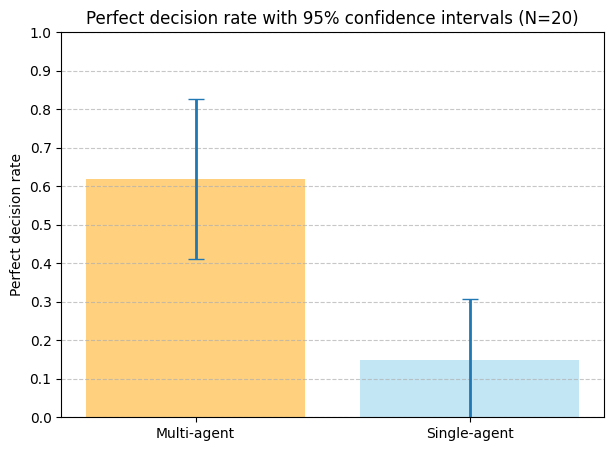

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

agents = ["Multi-agent", "Single-agent"]
successes = [13, 3]
totals = [21, 20]
rates = [k/n for k, n in zip(successes, totals)]

cis = [wald_ci(k, n) for k, n in zip(successes, totals)]
lower_err = [r - ci[0] for r, ci in zip(rates, cis)]
upper_err = [ci[1] - r for r, ci in zip(rates, cis)]

x = np.arange(len(agents))

plt.figure(figsize=(7,5))
plt.bar(x, rates, alpha=0.5, color=['orange', 'skyblue'])
plt.errorbar(
    x, rates,
    yerr=[lower_err, upper_err],
    fmt='none',
    capsize=6,
    linewidth=2
)
plt.xticks(x, agents)
plt.ylabel("Perfect decision rate")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Perfect decision rate with 95% confidence intervals (N=20)")
plt.show()

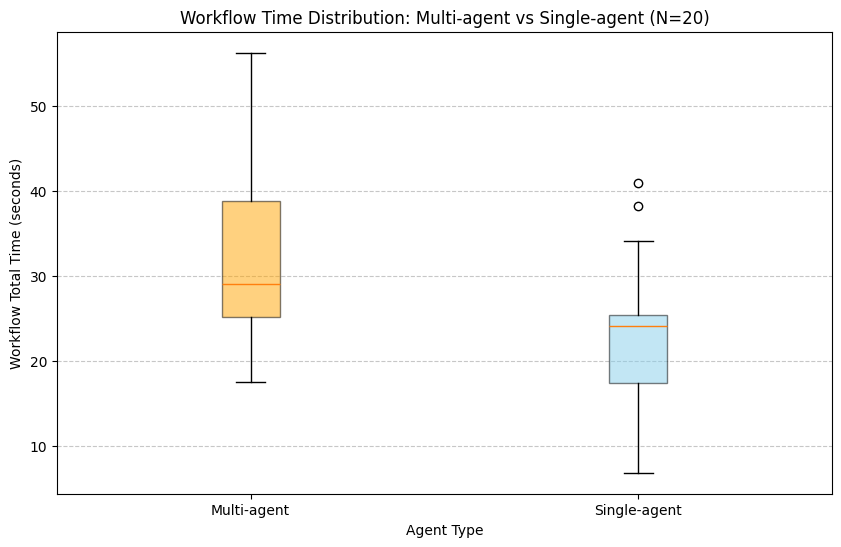

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for plotting
multi_agent_times = multi[['workflow_total_time']].copy()
multi_agent_times['Agent_Type'] = 'Multi-agent'

single_agent_times = single[['workflow_total_time']].copy()
single_agent_times['Agent_Type'] = 'Single-agent'

combined_times = pd.concat([multi_agent_times, single_agent_times])

# Extract data for matplotlib boxplot
multi_data = combined_times[combined_times['Agent_Type'] == 'Multi-agent']['workflow_total_time']
single_data = combined_times[combined_times['Agent_Type'] == 'Single-agent']['workflow_total_time']

plt.figure(figsize=(10, 6))
bp = plt.boxplot([multi_data, single_data], patch_artist=True)

# Set colors for the boxes with transparency
colors = ['orange', 'skyblue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5) # Set transparency here

plt.xticks([1, 2], ['Multi-agent', 'Single-agent'])
plt.title('Workflow Time Distribution: Multi-agent vs Single-agent (N=20)')
plt.xlabel('Agent Type')
plt.ylabel('Workflow Total Time (seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

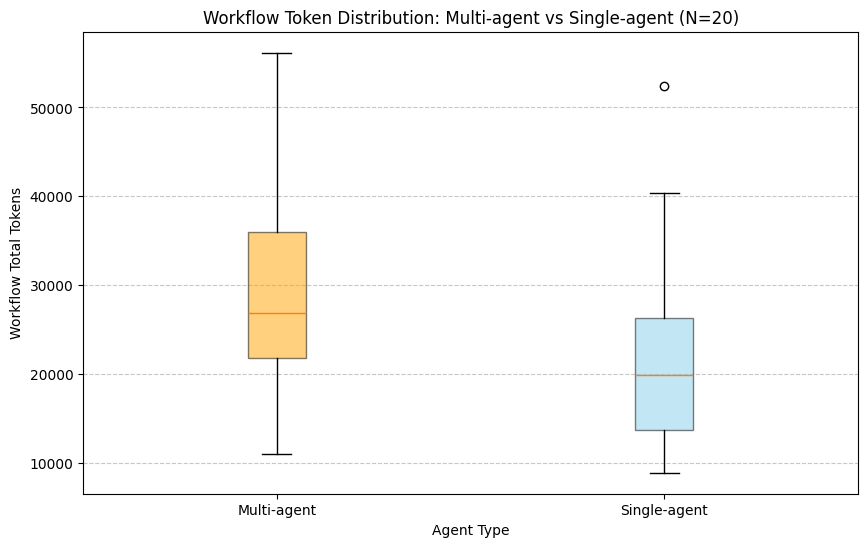

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for plotting for workflow_total_tokens
multi_agent_tokens = multi[['workflow_total_tokens']].copy()
multi_agent_tokens['Agent_Type'] = 'Multi-agent'

single_agent_tokens = single[['workflow_total_tokens']].copy()
single_agent_tokens['Agent_Type'] = 'Single-agent'

combined_tokens = pd.concat([multi_agent_tokens, single_agent_tokens])

# Extract data for matplotlib boxplot
multi_data_tokens = combined_tokens[combined_tokens['Agent_Type'] == 'Multi-agent']['workflow_total_tokens']
single_data_tokens = combined_tokens[combined_tokens['Agent_Type'] == 'Single-agent']['workflow_total_tokens']

plt.figure(figsize=(10, 6))
bp = plt.boxplot([multi_data_tokens, single_data_tokens], patch_artist=True)

# Set colors for the boxes with transparency
colors = ['orange', 'skyblue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5) # Set transparency here

plt.xticks([1, 2], ['Multi-agent', 'Single-agent'])
plt.title('Workflow Token Distribution: Multi-agent vs Single-agent (N=20)')
plt.xlabel('Agent Type')
plt.ylabel('Workflow Total Tokens')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Using perfect decision rate as the primary robustness metric, the multi-agent workflow outperformed the single-agent workflow (61.9% vs 15.0%). The estimated 95% Wilson confidence intervals were [40.9%, 79.2%] for multi-agent and [5.2%, 36.0%] for single-agent. The estimated difference in proportions was 46.9 percentage points, with a 95% confidence interval of approximately [17.2, 66.8] percentage points. While the number of runs per condition was modest, the observed effect was large enough to provide meaningful evidence in favor of the multi-agent design on this task.

# **Case 2: Simple descriptive analysis: Single Agent vs Multi Agent**


## **Multi Agent**

In [ ]:
import json
from pathlib import Path
from datetime import datetime

n_iter = 1

input_path = "/content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/input/descriptive_analysis_dataset.csv"
agent_input = f"""Load the dataset and, excluding the target column Y, determine which pair of predictor columns has the highest Pearson correlation.
Report the pair, the correlation value, and a brief explanation. Dataset: {input_path}"""

# output_dir = Path("experiment_runs/correlation_leak_trap_v1/multi_agent")
output_dir = Path("/content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/multi_agent")
output_dir.mkdir(parents=True, exist_ok=True)

correlation_analysis_agents = build_agents(response_model = CorrelationAnalysisResult)

for i in range(n_iter):
  result = multi_agent_workflow(agent_input, correlation_analysis_agents, verbose=False)
  timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

  output_file = output_dir / f"multi_agent_run_{i}_{timestamp}.json"
  with open(output_file, "w") as f:
      json.dump(to_jsonable(result), f, indent=2)

  print(f"Saved multi-agent run {i} to {output_file}")

INFO     Saved: /content/load_and_analyze_dataset.py

INFO     Running /content/load_and_analyze_dataset.py

INFO     Saved: /content/load_and_analyze_dataset.py

INFO     Running /content/load_and_analyze_dataset.py

INFO     Saved: /content/load_and_analyze_dataset.py

...

INFO     Saved: /content/revised_analysis.py

INFO     Running /content/revised_analysis.py

INFO     Saved: /content/inspect_dataset.py

INFO     Running /content/inspect_dataset.py

Saved multi-agent run 0 to /content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/multi_agent/multi_agent_run_0_20260412_041456_711143.json


In [ ]:
import json
from pathlib import Path
import pandas as pd

dir_path = Path("/content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/multi_agent")

rows = []

for file_path in sorted(dir_path.glob("*.json")):
    with open(file_path, "r") as f:
        data = json.load(f)
    print(f"processing: {file_path}")
    analyst = data.get("analyst", {})
    critic = data.get("critic", {})
    refiner = data.get("refiner", {})
    workflow_totals = data.get("workflow_totals", {})

    analyst_output = analyst.get("output", {})
    refiner_output = refiner.get("output", {})

    row = {
        "file_name": file_path.name,
        "agent_input": data.get("agent_input"),

        # workflow totals
        "workflow_total_time": workflow_totals.get("total_time"),
        "workflow_total_tokens": workflow_totals.get("total_tokens"),

        # agent-level summaries
        "analyst_total_time": analyst.get("metrics_summary", {}).get("total_time"),
        "analyst_total_tokens": analyst.get("metrics_summary", {}).get("total_tokens"),
        "critic_total_time": critic.get("metrics_summary", {}).get("total_time"),
        "critic_total_tokens": critic.get("metrics_summary", {}).get("total_tokens"),
        "refiner_total_time": refiner.get("metrics_summary", {}).get("total_time"),
        "refiner_total_tokens": refiner.get("metrics_summary", {}).get("total_tokens"),

        # analyst output
        "analyst_task_type": analyst_output.get("task_type"),
        "analyst_variable_1": analyst_output.get("variable_1"),
        "analyst_variable_2": analyst_output.get("variable_2"),
        "analyst_correlation_value": analyst_output.get("correlation_value"),
        "analyst_final_conclusion": analyst_output.get("final_conclusion"),

        # critic output
        "critic_output": critic.get("output"),

        # refiner output (final answer)
        "final_task_type": refiner_output.get("task_type"),
        "final_variable_1": refiner_output.get("variable_1"),
        "final_variable_2": refiner_output.get("variable_2"),
        "final_correlation_value": refiner_output.get("correlation_value"),
        "final_conclusion": refiner_output.get("final_conclusion"),
    }

    rows.append(row)

df = pd.DataFrame(rows)
df.head(20)
df.to_csv("/content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/multi_agent_output.csv")

processing: /content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/multi_agent/multi_agent_run_0_20260412_030100_289402.json
processing: /content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/multi_agent/multi_agent_run_0_20260412_033154_288812.json
processing: /content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/multi_agent/multi_agent_run_0_20260412_033816_691355.json
processing: /content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/multi_agent/multi_agent_run_0_20260412_034938_301985.json
processing: /content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/multi_agent/multi_agent_run_0_20260412_040507_229336.json
processing: /content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/multi_agent/multi_agent_run_0_20260412_040917_620105.json
processing: /content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/m

In [ ]:
result

{'agent_input': 'Load the dataset and determine which pair of independent variables has the highest Pearson correlation. \n                  Report the pair, the correlation value, and a brief explanation. - /content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/input/descriptive_analysis_dataset.csv',
 'analyst': {'output': CorrelationAnalysisResult(task_type='Pearson Correlation', variable_1='Y', variable_2='leak', correlation_value=0.9997959552349349, final_conclusion="The pair of variables 'Y' and 'leak' has the highest Pearson correlation in the dataset with a correlation value of approximately 0.9998. This extremely high correlation suggests that 'leak' may be a redundant or possibly a leakage feature directly related to the target 'Y'. This calls for further investigation to ensure 'leak' is suitable for use in predictive modeling."),
  'metrics_raw': defaultdict(list,
              {'time': [2.773230697001054,
                0.6274315559985553,
             

## **Single Agent**

In [ ]:
# Experiment - Multiple runs

import json
from pathlib import Path
from datetime import datetime

n_iter = 5

input_path = "/content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/input/descriptive_analysis_dataset.csv"
agent_input = f"""Load the dataset and, excluding the target column Y, determine which pair of predictor columns has the highest Pearson correlation.
Report the pair, the correlation value, and a brief explanation. Dataset: {input_path}"""

# output_dir = Path("experiment_runs/correlation_leak_trap_v1/multi_agent")
output_dir = Path("/content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/single_agent")
output_dir.mkdir(parents=True, exist_ok=True)

correlation_analysis_agents = build_agents(response_model = CorrelationAnalysisResult)

for i in range(n_iter):
  result = single_agent_workflow(agent_input, correlation_analysis_agents, verbose=False)
  timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

  output_file = output_dir / f"single_agent_run_{i}_{timestamp}.json"
  with open(output_file, "w") as f:
      json.dump(to_jsonable(result), f, indent=2)

  print(f"Saved single-agent run {i} to {output_file}")

INFO     Saved: /content/load_and_analyze.py

INFO     Running /content/load_and_analyze.py

INFO     Saved: /content/load_and_analyze.py

INFO     Running /content/load_and_analyze.py

INFO     Saved: /content/load_and_analyze_v2.py

...

INFO     Saved: /content/load_and_analyze.py

INFO     Running /content/load_and_analyze.py

INFO     Saved: /content/load_and_analyze.py

INFO     Running /content/load_and_analyze.py

('A', 'leak')
0.31925837821932423
Saved single-agent run 4 to /content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/single_agent/single_agent_run_4_20260412_041624_519754.json


In [ ]:
import json
from pathlib import Path
import pandas as pd

dir_path = Path("/content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/single_agent")

rows = []

def ensure_dict(x):
    if isinstance(x, dict):
        return x
    return {}

for file_path in sorted(dir_path.glob("*.json")):
    with open(file_path, "r") as f:
        data = json.load(f)

    single_agent = data.get("single_agent", {})
    workflow_totals = data.get("workflow_totals", {})

    single_output = ensure_dict(single_agent.get("output", {}))

    row = {
        "file_name": file_path.name,
        "agent_input": data.get("agent_input"),

        # workflow totals
        "workflow_total_time": workflow_totals.get("total_time"),
        "workflow_total_tokens": workflow_totals.get("total_tokens"),

        # single-agent metrics
        "single_total_time": single_agent.get("metrics_summary", {}).get("total_time"),
        "single_total_tokens": single_agent.get("metrics_summary", {}).get("total_tokens"),

        # final output
        "task_type": single_output.get("task_type"),
        "final_variable_1": single_output.get("variable_1"),
        "final_variable_2": single_output.get("variable_2"),
        "final_correlation_value": single_output.get("correlation_value"),
        "final_conclusion": single_output.get("final_conclusion"),
    }

    rows.append(row)

df = pd.DataFrame(rows)
df.head(20)
df.to_csv("/content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/single_agent_output.csv")

## **Compare Single vs Multi Agent**

In [5]:
# Load files -- Pre-requisite for the following cells to run
multi = pd.read_csv("/content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/multi_agent_output.csv")
single = pd.read_csv("/content/drive/MyDrive/SingleAgentVsMultiAgent/case2_descriptive_analysis/output/single_agent_output.csv")


In [ ]:
import pandas as pd

TARGET_VAR1 = "A"
TARGET_VAR2 = "leak"
TARGET_CORR = 0.319258
TOL = 1e-4  # tolerance for floating-point comparison

def normalize_pair(v1, v2):
    return tuple(sorted([str(v1).strip(), str(v2).strip()]))

target_pair = normalize_pair(TARGET_VAR1, TARGET_VAR2)

def perfect_decision(row):
    pred_pair = normalize_pair(row["final_variable_1"], row["final_variable_2"])
    corr_ok = pd.notna(row["final_correlation_value"]) and abs(row["final_correlation_value"] - TARGET_CORR) <= TOL
    return (pred_pair == target_pair) and corr_ok

def summarize(df, agent_name):
    return {
        "agent": agent_name,
        "runs": len(df),
        "perfect_decision_rate": df.apply(perfect_decision, axis=1).mean(),
        "mean_workflow_tokens": df["workflow_total_tokens"].mean(),
        "mean_workflow_time": df["workflow_total_time"].mean(),
    }

results = pd.DataFrame([
    summarize(multi, "Multi-agent"),
    summarize(single, "Single-agent")
])

results.head()

,agent,runs,perfect_decision_rate,mean_workflow_tokens,mean_workflow_time
0,Multi-agent,20,0.75,19059.75,20.201926
1,Single-agent,20,0.80,8673.10,8.002019


In [7]:
import math

def wilson_ci(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = z * math.sqrt((p*(1-p) + z**2/(4*n)) / n) / denom
    return center - half, center + half

def wald_ci(k, n, z=1.96):
    p = k / n
    se = math.sqrt(p * (1 - p) / n)
    return p - z * se, p + z * se

multi_k, multi_n = 15, 20
single_k, single_n = 16, 20

multi_ci = wald_ci(multi_k, multi_n)
single_ci = wald_ci(single_k, single_n)

print("Multi-agent rate:", multi_k / multi_n)
print("Multi-agent 95% CI:", multi_ci)

print("Single-agent rate:", single_k / single_n)
print("Single-agent 95% CI:", single_ci)

Multi-agent rate: 0.75
Multi-agent 95% CI: (0.5602238160358366, 0.9397761839641634)
Single-agent rate: 0.8
Single-agent 95% CI: (0.6246922705640165, 0.9753077294359835)


In [ ]:
from statsmodels.stats.proportion import confint_proportions_2indep
from scipy.stats import fisher_exact

multi_k, multi_n = 15, 20
single_k, single_n = 16, 20

# 95% CI for difference in proportions
ci_low, ci_high = confint_proportions_2indep(
    count1=multi_k, nobs1=multi_n,
    count2=single_k, nobs2=single_n,
    method="newcomb"
)

diff = multi_k / multi_n - single_k / single_n
print("Difference in perfect_decision_rate:", diff)
print("95% CI for difference:", (ci_low, ci_high))

# Fisher exact test
table = [
    [multi_k, multi_n - multi_k],
    [single_k, single_n - single_k]
]

odds_ratio, p_value = fisher_exact(table)
print("Fisher exact odds ratio:", odds_ratio)
print("Fisher exact p-value:", p_value)

Difference in perfect_decision_rate: -0.050000000000000044
95% CI for difference: (np.float64(-0.2991438688230683), np.float64(0.20640928332392017))
Fisher exact odds ratio: 0.75
Fisher exact p-value: 1.0


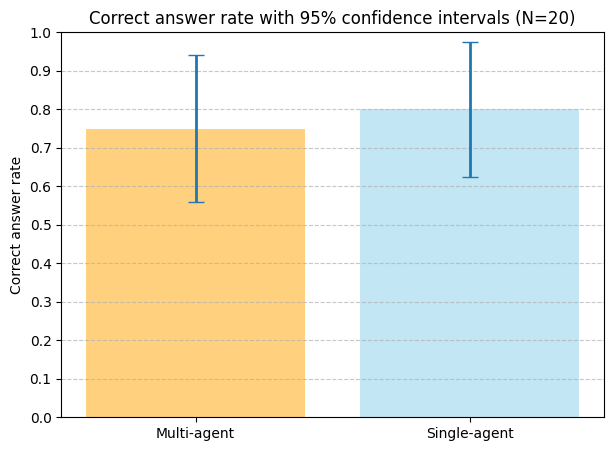

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import math

agents = ["Multi-agent", "Single-agent"]
successes = [15, 16]
totals = [20, 20]
rates = [k/n for k, n in zip(successes, totals)]

cis = [wald_ci(k, n) for k, n in zip(successes, totals)]
lower_err = [r - ci[0] for r, ci in zip(rates, cis)]
upper_err = [ci[1] - r for r, ci in zip(rates, cis)]

x = np.arange(len(agents))

plt.figure(figsize=(7,5))
plt.bar(x, rates, alpha=0.5, color=['orange', 'skyblue'])
plt.errorbar(
    x, rates,
    yerr=[lower_err, upper_err],
    fmt='none',
    capsize=6,
    linewidth=2
)
plt.xticks(x, agents)
plt.ylabel("Correct answer rate")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Correct answer rate with 95% confidence intervals (N=20)")
plt.show()

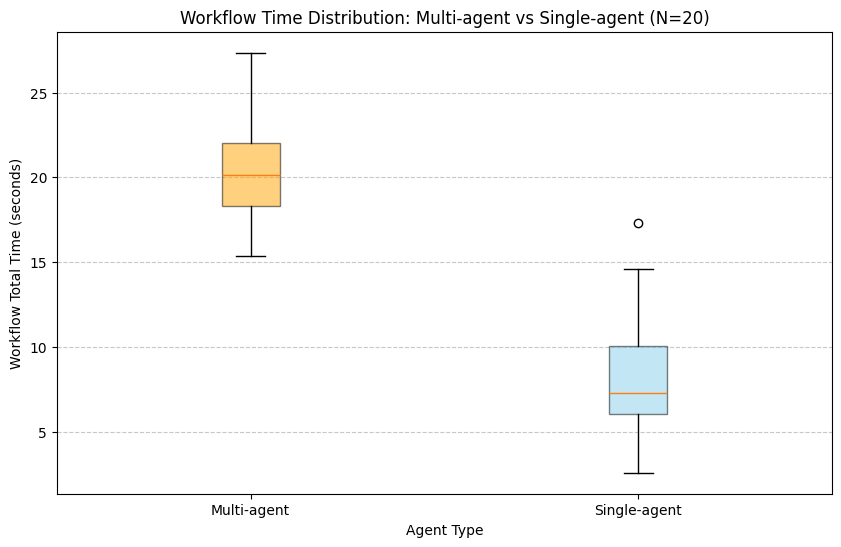

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for plotting
multi_agent_times = multi[['workflow_total_time']].copy()
multi_agent_times['Agent_Type'] = 'Multi-agent'

single_agent_times = single[['workflow_total_time']].copy()
single_agent_times['Agent_Type'] = 'Single-agent'

combined_times = pd.concat([multi_agent_times, single_agent_times])

# Extract data for matplotlib boxplot
multi_data = combined_times[combined_times['Agent_Type'] == 'Multi-agent']['workflow_total_time']
single_data = combined_times[combined_times['Agent_Type'] == 'Single-agent']['workflow_total_time']

plt.figure(figsize=(10, 6))
bp = plt.boxplot([multi_data, single_data], patch_artist=True)

# Set colors for the boxes with transparency
colors = ['orange', 'skyblue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5) # Set transparency here

plt.xticks([1, 2], ['Multi-agent', 'Single-agent'])
plt.title('Workflow Time Distribution: Multi-agent vs Single-agent (N=20)')
plt.xlabel('Agent Type')
plt.ylabel('Workflow Total Time (seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

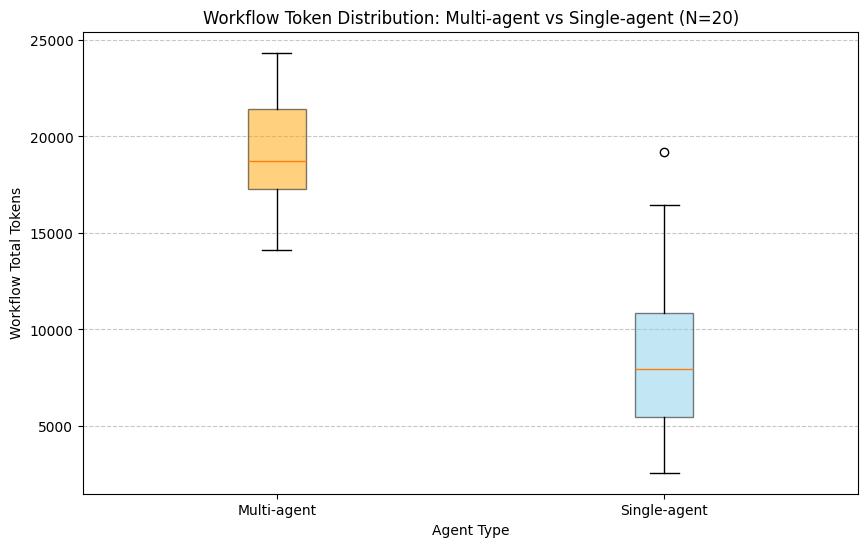

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for plotting for workflow_total_tokens
multi_agent_tokens = multi[['workflow_total_tokens']].copy()
multi_agent_tokens['Agent_Type'] = 'Multi-agent'

single_agent_tokens = single[['workflow_total_tokens']].copy()
single_agent_tokens['Agent_Type'] = 'Single-agent'

combined_tokens = pd.concat([multi_agent_tokens, single_agent_tokens])

# Extract data for matplotlib boxplot
multi_data_tokens = combined_tokens[combined_tokens['Agent_Type'] == 'Multi-agent']['workflow_total_tokens']
single_data_tokens = combined_tokens[combined_tokens['Agent_Type'] == 'Single-agent']['workflow_total_tokens']

plt.figure(figsize=(10, 6))
bp = plt.boxplot([multi_data_tokens, single_data_tokens], patch_artist=True)

# Set colors for the boxes with transparency
colors = ['orange', 'skyblue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5) # Set transparency here

plt.xticks([1, 2], ['Multi-agent', 'Single-agent'])
plt.title('Workflow Token Distribution: Multi-agent vs Single-agent (N=20)')
plt.xlabel('Agent Type')
plt.ylabel('Workflow Total Tokens')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()